# Raw Dataset Investigation: NavSim vs Bench2Drive

This notebook investigates the original datasets before they are processed into cache files.
We'll compare the raw data formats, coordinate systems, and value ranges to understand
the fundamental differences between NavSim and Bench2Drive datasets.

## Key Questions to Answer:
1. What are the coordinate system differences?
2. What are the raw data value ranges?
3. How is the data structured differently?
4. Where do extreme values come from?

## 1. Setup and Imports

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pickle
import gzip
import json
from PIL import Image
import pandas as pd
from tqdm import tqdm
import warnings
import os

warnings.filterwarnings("ignore")

# Add project root to path
sys.path.append(str(Path.cwd().parent))

# Import necessary modules for NavSim
from navsim.common.dataloader import SceneLoader
from navsim.common.dataclasses import SceneFilter, SensorConfig, Scene
from navsim.common.bench2drive_dataloader import load_bench2drive_annotation

# Set paths
NAVSIM_RAW = Path("/workspace/navsim_workspace/dataset")
B2D_RAW = Path("/workspace/Bench2Drive-Base")

# Set NavSim environment variable if not set
if "OPENSCENE_DATA_ROOT" not in os.environ:
    os.environ["OPENSCENE_DATA_ROOT"] = str(NAVSIM_RAW)

print(f"NavSim raw data: {NAVSIM_RAW}")
print(f"Bench2Drive raw data: {B2D_RAW}")
print(f"NavSim exists: {NAVSIM_RAW.exists()}")
print(f"Bench2Drive exists: {B2D_RAW.exists()}")

NavSim raw data: /workspace/navsim_workspace/dataset
Bench2Drive raw data: /workspace/Bench2Drive-Base
NavSim exists: True
Bench2Drive exists: True


## 2. NavSim Raw Data Investigation

In [2]:
# List NavSim structure and load data using SceneLoader
print("=== NavSim Dataset Structure ===")
navsim_logs = NAVSIM_RAW / "navsim_logs" / "trainval"
sensor_blobs = NAVSIM_RAW / "sensor_blobs" / "trainval"

print(f"\nNavSim logs directory: {navsim_logs}")
print(f"Sensor blobs directory: {sensor_blobs}")

# Count files
log_files = list(navsim_logs.glob("*.pkl"))
print(f"\nNumber of log files: {len(log_files)}")

# Show sample log files
print("\nSample log files:")
for f in log_files[:5]:
    print(f"  {f.name}")

# Create SceneLoader for NavSim data
print("\n=== Loading NavSim data with SceneLoader ===")

# Create scene filter - load all scenes, sample 100 for analysis
scene_filter = SceneFilter(
    num_history_frames=4,
    num_future_frames=10,
    has_route=True,
    max_scenes=100,  # Limit to 100 scenes for faster loading
)

# Initialize SceneLoader - no sensors needed for ego state analysis
sensor_config = SensorConfig(
    cam_f0=False,
    cam_l0=False,
    cam_l1=False,
    cam_l2=False,
    cam_r0=False,
    cam_r1=False,
    cam_r2=False,
    cam_b0=False,
    lidar_pc=False,
)

scene_loader = SceneLoader(
    navsim_logs,
    sensor_blobs,
    scene_filter,
    sensor_config=sensor_config,
)

print(f"\nSceneLoader initialized with {len(scene_loader.tokens)} scenes")

=== NavSim Dataset Structure ===

NavSim logs directory: /workspace/navsim_workspace/dataset/navsim_logs/trainval
Sensor blobs directory: /workspace/navsim_workspace/dataset/sensor_blobs/trainval

Number of log files: 1310

Sample log files:
  2021.06.09.11.54.15_veh-12_05543_05765.pkl
  2021.07.09.17.06.37_veh-35_02609_05015.pkl
  2021.06.14.13.27.42_veh-35_04596_04692.pkl
  2021.08.17.19.18.39_veh-08_00696_00823.pkl
  2021.10.06.13.21.47_veh-28_00441_00515.pkl

=== Loading NavSim data with SceneLoader ===


Loading logs:   0%|          | 1/1310 [00:00<11:06,  1.97it/s]


SceneLoader initialized with 100 scenes


In [3]:
# Load and analyze NavSim scenes
print("=== Analyzing NavSim Scene Structure ===")

# Get a sample scene
sample_token = scene_loader.tokens[0]
sample_scene = scene_loader.get_scene_from_token(sample_token)

print(f"\nLoaded scene with token: {sample_token}")
print(f"Scene type: {type(sample_scene)}")
print(f"Number of frames: {len(sample_scene.frames)}")

# Analyze scene metadata
print(f"\nScene metadata:")
print(f"  Log name: {sample_scene.scene_metadata.log_name}")
print(f"  Map name: {sample_scene.scene_metadata.map_name}")
print(f"  History frames: {sample_scene.scene_metadata.num_history_frames}")
print(f"  Future frames: {sample_scene.scene_metadata.num_future_frames}")

# Analyze first frame
frame = sample_scene.frames[0]
print(f"\nFirst frame analysis:")
print(f"  Frame type: {type(frame)}")
print(f"  Token: {frame.token}")
print(f"  Timestamp: {frame.timestamp}")

# Analyze ego status
ego = frame.ego_status
print(f"\nEgo status:")
print(f"  Type: {type(ego)}")
print(f"  In global frame: {ego.in_global_frame}")
print(f"  Ego pose shape: {ego.ego_pose.shape} (SE2: x, y, heading)")
print(f"  Ego velocity shape: {ego.ego_velocity.shape}")
print(f"  Ego acceleration shape: {ego.ego_acceleration.shape}")
print(f"  Driving command shape: {ego.driving_command.shape}")

# Show sample values
print(f"\nSample ego values from first frame:")
print(f"  Position (x, y): ({ego.ego_pose[0]:.2f}, {ego.ego_pose[1]:.2f}) m")
print(f"  Heading: {ego.ego_pose[2]:.3f} rad")
print(f"  Velocity: {ego.ego_velocity} m/s")
print(f"  Acceleration: {ego.ego_acceleration} m/s²")
print(f"  Driving command: {ego.driving_command}")

=== Analyzing NavSim Scene Structure ===

Loaded scene with token: 4f3cd6ab985956ff
Scene type: <class 'navsim.common.dataclasses.Scene'>
Number of frames: 14

Scene metadata:
  Log name: 2021.06.09.11.54.15_veh-12_05543_05765
  Map name: us-nv-las-vegas-strip
  History frames: 4
  Future frames: 10

First frame analysis:
  Frame type: <class 'navsim.common.dataclasses.Frame'>
  Token: 1525316f55a15c2a
  Timestamp: 1623259732100116

Ego status:
  Type: <class 'navsim.common.dataclasses.EgoStatus'>
  In global frame: True
  Ego pose shape: (3,) (SE2: x, y, heading)
  Ego velocity shape: (2,)
  Ego acceleration shape: (2,)
  Driving command shape: (4,)

Sample ego values from first frame:
  Position (x, y): (664437.67, 3997071.10) m
  Heading: -1.557 rad
  Velocity: [ 3.4469333  -0.05844042] m/s
  Acceleration: [ 1.4115561  -0.02066662] m/s²
  Driving command: [0 1 0 0]


In [4]:
# Extract NavSim statistics from all loaded scenes
print("=== NavSim Data Statistics (All Scenes) ===")

nav_stats = {
    "ego_x": [],
    "ego_y": [],
    "ego_heading": [],
    "ego_vx": [],
    "ego_vy": [],
    "ego_ax": [],
    "ego_ay": [],
    "velocity_magnitude": [],
    "acceleration_magnitude": [],
}

# Process all loaded scenes
for token in tqdm(scene_loader.tokens, desc="Processing NavSim scenes"):
    scene = scene_loader.get_scene_from_token(token)

    # Process all frames in the scene
    for frame in scene.frames:
        ego = frame.ego_status

        # Extract position from ego_pose (SE2: x, y, heading)
        nav_stats["ego_x"].append(ego.ego_pose[0])
        nav_stats["ego_y"].append(ego.ego_pose[1])
        nav_stats["ego_heading"].append(ego.ego_pose[2])

        # Extract velocity
        nav_stats["ego_vx"].append(ego.ego_velocity[0])
        nav_stats["ego_vy"].append(ego.ego_velocity[1])
        vel_mag = np.sqrt(ego.ego_velocity[0] ** 2 + ego.ego_velocity[1] ** 2)
        nav_stats["velocity_magnitude"].append(vel_mag)

        # Extract acceleration
        nav_stats["ego_ax"].append(ego.ego_acceleration[0])
        nav_stats["ego_ay"].append(ego.ego_acceleration[1])
        acc_mag = np.sqrt(ego.ego_acceleration[0] ** 2 + ego.ego_acceleration[1] ** 2)
        nav_stats["acceleration_magnitude"].append(acc_mag)

print(f"\nProcessed {len(nav_stats['ego_x'])} frames from {len(scene_loader.tokens)} scenes")

# Print statistics
for key, values in nav_stats.items():
    if values:
        print(f"\n{key}:")
        print(f"  Count: {len(values)}")
        print(f"  Range: [{np.min(values):.3f}, {np.max(values):.3f}]")
        print(f"  Mean: {np.mean(values):.3f}, Std: {np.std(values):.3f}")

=== NavSim Data Statistics (All Scenes) ===


Processing NavSim scenes: 100%|██████████| 100/100 [00:00<00:00, 1000.41it/s]


Processed 1400 frames from 100 scenes

ego_x:
  Count: 1400
  Range: [664195.920, 664597.554]
  Mean: 664460.426, Std: 80.647

ego_y:
  Count: 1400
  Range: [3996283.248, 3997902.763]
  Mean: 3997217.708, Std: 621.727

ego_heading:
  Count: 1400
  Range: [-3.141, 3.103]
  Mean: 0.128, Std: 1.926

ego_vx:
  Count: 1400
  Range: [-0.024, 12.648]
  Mean: 3.702, Std: 3.958

ego_vy:
  Count: 1400
  Range: [-0.284, 0.030]
  Mean: -0.068, Std: 0.075

ego_ax:
  Count: 1400
  Range: [-1.831, 2.331]
  Mean: -0.004, Std: 0.504

ego_ay:
  Count: 1400
  Range: [-2.344, 1.151]
  Mean: -0.007, Std: 0.240

velocity_magnitude:
  Count: 1400
  Range: [0.000, 12.650]
  Mean: 3.704, Std: 3.958

acceleration_magnitude:
  Count: 1400
  Range: [0.002, 2.370]
  Mean: 0.372, Std: 0.417


In [5]:
# Extract driving commands from NavSim
print("\n=== NavSim Driving Commands ===")

nav_commands = []
for token in scene_loader.tokens[:20]:  # Sample first 20 scenes
    scene = scene_loader.get_scene_from_token(token)
    for frame in scene.frames:
        nav_commands.extend(frame.ego_status.driving_command.tolist())

if nav_commands:
    unique_commands = np.unique(nav_commands)
    print(f"Unique driving commands: {unique_commands}")

    # Count occurrences
    cmd_counts = pd.Series(nav_commands).value_counts().sort_index()
    print("\nDriving command distribution:")
    print(cmd_counts)


=== NavSim Driving Commands ===
Unique driving commands: [0 1]

Driving command distribution:
0    840
1    280
Name: count, dtype: int64


In [6]:
# List Bench2Drive structure
print("=== Bench2Drive Dataset Structure ===")

# Get scenario folders
scenarios = [d for d in B2D_RAW.iterdir() if d.is_dir() and not d.name.startswith(".")]
print(f"\nNumber of scenarios: {len(scenarios)}")

# Show sample scenarios
print("\nSample scenarios:")
for s in scenarios[:5]:
    anno_count = len(list((s / "anno").glob("*.json.gz"))) if (s / "anno").exists() else 0
    print(f"  {s.name} - {anno_count} frames")

=== Bench2Drive Dataset Structure ===

Number of scenarios: 1000

Sample scenarios:
  VehicleTurningRoute_Town12_Route997_Weather9 - 541 frames
  InterurbanAdvancedActorFlow_Town06_Route325_Weather13 - 114 frames
  OppositeVehicleTakingPriority_Town13_Route600_Weather2 - 134 frames
  HighwayExit_Town06_Route313_Weather1 - 164 frames
  VehicleTurningRoutePedestrian_Town13_Route680_Weather10 - 149 frames


In [7]:
# Load and analyze Bench2Drive annotations
sample_scenario = scenarios[0]
print(f"Analyzing scenario: {sample_scenario.name}")

# Load first few annotations
anno_files = sorted((sample_scenario / "anno").glob("*.json.gz"))[:10]
print(f"Found {len(anno_files)} annotation files")

# Load first annotation
if anno_files:
    anno = load_bench2drive_annotation(anno_files[0])
    print(f"\nFirst annotation keys: {list(anno.keys())}")

    # Show sample values
    print(f"\nSample values:")
    print(
        f"  Position: x={anno.get('x', 'N/A')}, y={anno.get('y', 'N/A')}, z={anno.get('z', 'N/A')}"
    )
    print(f"  Rotation: theta={anno.get('theta', 'N/A')}")
    print(f"  Velocity: {anno.get('velocity', 'N/A')}")
    print(f"  Speed: {anno.get('speed', 'N/A')}")
    print(f"  Acceleration: {anno.get('acceleration', 'N/A')}")

Analyzing scenario: VehicleTurningRoute_Town12_Route997_Weather9
Found 10 annotation files

First annotation keys: ['x', 'y', 'throttle', 'steer', 'brake', 'reverse', 'theta', 'speed', 'x_command_far', 'y_command_far', 'command_far', 'x_command_near', 'y_command_near', 'command_near', 'should_brake', 'x_target', 'y_target', 'next_command', 'weather', 'acceleration', 'angular_velocity', 'bounding_boxes', 'sensors', 'only_ap_brake']

Sample values:
  Position: x=1672.0657399753952, y=4250.135359272905, z=N/A
  Rotation: theta=3.303769588470459
  Velocity: N/A
  Speed: 0.0
  Acceleration: [0.1344965249300003, 0.0006041557062417269, 9.78921890258789]


In [8]:
# Extract Bench2Drive statistics from multiple frames
print("=== Bench2Drive Data Statistics (1000 frames from multiple scenarios) ===")

b2d_stats = {
    "ego_x": [],
    "ego_y": [],
    "ego_z": [],
    "ego_theta": [],
    "ego_speed": [],
    "ego_velocity": [],
    "ego_acceleration": [],
    "command_near": [],
    "command_far": [],
}

# Sample from multiple scenarios
total_frames = 0
for scenario in tqdm(scenarios[:10], desc="Processing scenarios"):
    anno_files = sorted((scenario / "anno").glob("*.json.gz"))[:100]

    for anno_file in anno_files:
        try:
            anno = load_bench2drive_annotation(anno_file)

            # Extract values
            b2d_stats["ego_x"].append(anno.get("x", 0))
            b2d_stats["ego_y"].append(anno.get("y", 0))
            b2d_stats["ego_z"].append(anno.get("z", 0))
            b2d_stats["ego_theta"].append(anno.get("theta", 0))
            b2d_stats["ego_speed"].append(anno.get("speed", 0))

            # Velocity might be a list or dict
            vel = anno.get("velocity", [0, 0, 0])
            if isinstance(vel, (list, tuple)) and len(vel) >= 2:
                b2d_stats["ego_velocity"].append([vel[0], vel[1]])

            # Acceleration might be a list or dict
            acc = anno.get("acceleration", [0, 0, 0])
            if isinstance(acc, (list, tuple)) and len(acc) >= 2:
                b2d_stats["ego_acceleration"].append([acc[0], acc[1]])

            b2d_stats["command_near"].append(anno.get("command_near", -1))
            b2d_stats["command_far"].append(anno.get("command_far", -1))

            total_frames += 1
            if total_frames >= 1000:
                break
        except Exception as e:
            continue

    if total_frames >= 1000:
        break

print(f"\nProcessed {total_frames} frames")

# Print statistics
for key, values in b2d_stats.items():
    if values and key not in ["ego_velocity", "ego_acceleration"]:
        print(f"\n{key}:")
        print(f"  Count: {len(values)}")
        print(f"  Range: [{np.min(values):.3f}, {np.max(values):.3f}]")
        print(f"  Mean: {np.mean(values):.3f}, Std: {np.std(values):.3f}")

# Special handling for velocity and acceleration
if b2d_stats["ego_velocity"]:
    vel_array = np.array(b2d_stats["ego_velocity"])
    print(f"\nego_velocity_x:")
    print(f"  Range: [{np.min(vel_array[:, 0]):.3f}, {np.max(vel_array[:, 0]):.3f}]")
    print(f"  Mean: {np.mean(vel_array[:, 0]):.3f}, Std: {np.std(vel_array[:, 0]):.3f}")
    print(f"\nego_velocity_y:")
    print(f"  Range: [{np.min(vel_array[:, 1]):.3f}, {np.max(vel_array[:, 1]):.3f}]")
    print(f"  Mean: {np.mean(vel_array[:, 1]):.3f}, Std: {np.std(vel_array[:, 1]):.3f}")

if b2d_stats["ego_acceleration"]:
    acc_array = np.array(b2d_stats["ego_acceleration"])
    print(f"\nego_acceleration_x:")
    print(f"  Range: [{np.min(acc_array[:, 0]):.3f}, {np.max(acc_array[:, 0]):.3f}]")
    print(f"  Mean: {np.mean(acc_array[:, 0]):.3f}, Std: {np.std(acc_array[:, 0]):.3f}")
    print(f"\nego_acceleration_y:")
    print(f"  Range: [{np.min(acc_array[:, 1]):.3f}, {np.max(acc_array[:, 1]):.3f}]")
    print(f"  Mean: {np.mean(acc_array[:, 1]):.3f}, Std: {np.std(acc_array[:, 1]):.3f}")

=== Bench2Drive Data Statistics (1000 frames from multiple scenarios) ===


Processing scenarios:  90%|█████████ | 9/10 [00:01<00:00,  6.96it/s]


Processed 1000 frames

ego_x:
  Count: 1000
  Range: [-760.432, 3261.933]
  Mean: 1472.907, Std: 1469.322

ego_y:
  Count: 1000
  Range: [49.394, 5855.938]
  Mean: 2998.255, Std: 2024.168

ego_z:
  Count: 1000
  Range: [0.000, 0.000]
  Mean: 0.000, Std: 0.000

ego_theta:
  Count: 1000
  Range: [0.159, 6.075]
  Mean: 2.709, Std: 1.676

ego_speed:
  Count: 1000
  Range: [-0.027, 13.254]
  Mean: 4.999, Std: 3.877

command_near:
  Count: 1000
  Range: [1.000, 5.000]
  Mean: 3.537, Std: 0.979

command_far:
  Count: 1000
  Range: [1.000, 5.000]
  Mean: 3.054, Std: 1.368

ego_velocity_x:
  Range: [0.000, 0.000]
  Mean: 0.000, Std: 0.000

ego_velocity_y:
  Range: [0.000, 0.000]
  Mean: 0.000, Std: 0.000

ego_acceleration_x:
  Range: [-27.044, 11.290]
  Mean: 0.600, Std: 4.452

ego_acceleration_y:
  Range: [-11.807, 9.207]
  Mean: -0.243, Std: 2.001


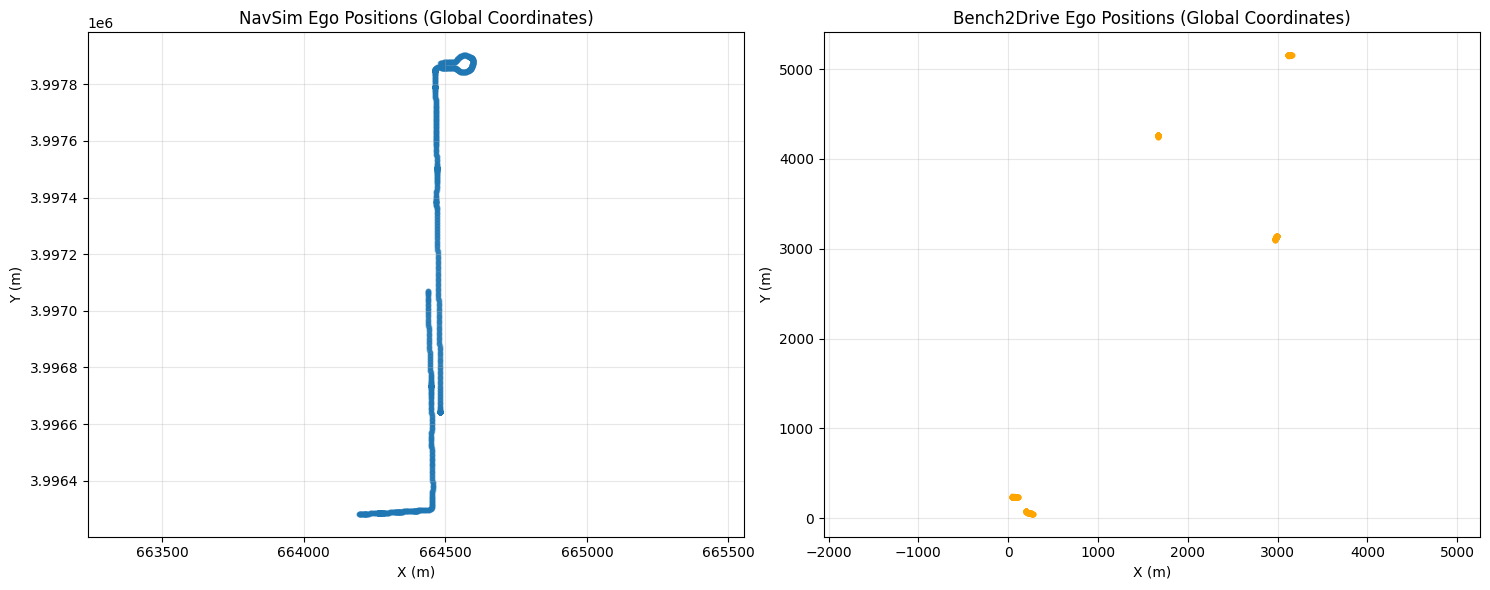


=== Coordinate System Observations ===
NavSim:
  - X range: [664195.9, 664597.6] m
  - Y range: [3996283.2, 3997902.8] m
  - Uses global world coordinates

Bench2Drive:
  - X range: [-760.4, 3261.9] m
  - Y range: [49.4, 5855.9] m
  - Uses CARLA world coordinates


In [9]:
# Visualize coordinate systems
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# NavSim coordinate system
if nav_stats["ego_x"] and nav_stats["ego_y"]:
    ax1.scatter(nav_stats["ego_x"], nav_stats["ego_y"], alpha=0.5, s=10)
    ax1.set_xlabel("X (m)")
    ax1.set_ylabel("Y (m)")
    ax1.set_title("NavSim Ego Positions (Global Coordinates)")
    ax1.grid(True, alpha=0.3)
    ax1.axis("equal")
else:
    ax1.text(
        0.5, 0.5, "No NavSim data available", ha="center", va="center", transform=ax1.transAxes
    )
    ax1.set_title("NavSim Ego Positions")

# Bench2Drive coordinate system
if b2d_stats["ego_x"] and b2d_stats["ego_y"]:
    ax2.scatter(
        b2d_stats["ego_x"][:500], b2d_stats["ego_y"][:500], alpha=0.5, s=10, color="orange"
    )
    ax2.set_xlabel("X (m)")
    ax2.set_ylabel("Y (m)")
    ax2.set_title("Bench2Drive Ego Positions (Global Coordinates)")
    ax2.grid(True, alpha=0.3)
    ax2.axis("equal")

plt.tight_layout()
plt.show()

# Print coordinate system observations
print("\n=== Coordinate System Observations ===")
if nav_stats["ego_x"]:
    print("NavSim:")
    print(f"  - X range: [{np.min(nav_stats['ego_x']):.1f}, {np.max(nav_stats['ego_x']):.1f}] m")
    print(f"  - Y range: [{np.min(nav_stats['ego_y']):.1f}, {np.max(nav_stats['ego_y']):.1f}] m")
    print("  - Uses global world coordinates")
else:
    print("NavSim: No position data extracted")

print("\nBench2Drive:")
print(f"  - X range: [{np.min(b2d_stats['ego_x']):.1f}, {np.max(b2d_stats['ego_x']):.1f}] m")
print(f"  - Y range: [{np.min(b2d_stats['ego_y']):.1f}, {np.max(b2d_stats['ego_y']):.1f}] m")
print("  - Uses CARLA world coordinates")

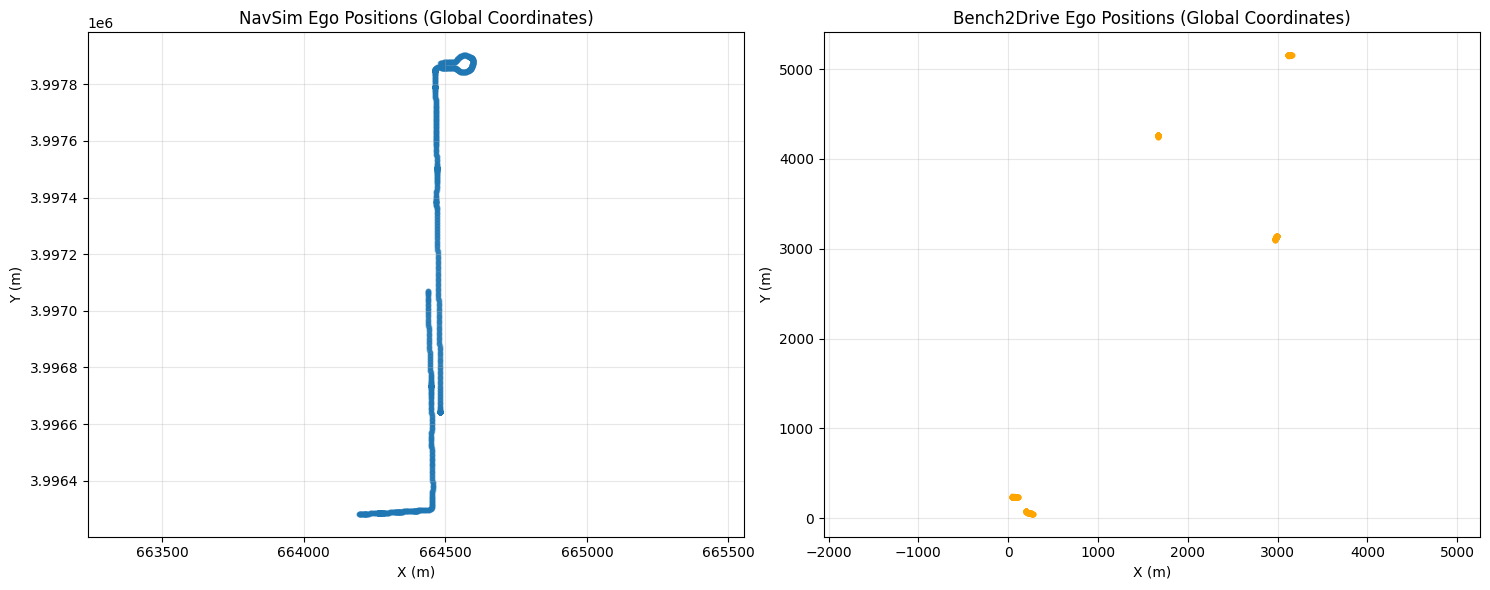


=== Coordinate System Observations ===
NavSim:
  - Appears to use global world coordinates
  - Large position values indicating absolute positions

Bench2Drive:
  - Also uses global coordinates (CARLA world)
  - Different map/scenario leads to different position ranges


In [10]:
# Visualize coordinate systems
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# NavSim coordinate system (if we have data)
if nav_stats["ego_x"] and nav_stats["ego_y"]:
    ax1.scatter(nav_stats["ego_x"], nav_stats["ego_y"], alpha=0.5, s=10)
    ax1.set_xlabel("X (m)")
    ax1.set_ylabel("Y (m)")
    ax1.set_title("NavSim Ego Positions (Global Coordinates)")
    ax1.grid(True, alpha=0.3)
    ax1.axis("equal")

# Bench2Drive coordinate system
if b2d_stats["ego_x"] and b2d_stats["ego_y"]:
    ax2.scatter(
        b2d_stats["ego_x"][:500], b2d_stats["ego_y"][:500], alpha=0.5, s=10, color="orange"
    )
    ax2.set_xlabel("X (m)")
    ax2.set_ylabel("Y (m)")
    ax2.set_title("Bench2Drive Ego Positions (Global Coordinates)")
    ax2.grid(True, alpha=0.3)
    ax2.axis("equal")

plt.tight_layout()
plt.show()

# Print coordinate system observations
print("\n=== Coordinate System Observations ===")
print("NavSim:")
print("  - Appears to use global world coordinates")
print("  - Large position values indicating absolute positions")
print("\nBench2Drive:")
print("  - Also uses global coordinates (CARLA world)")
print("  - Different map/scenario leads to different position ranges")

NavSim heading range: [-3.141, 3.103] radians
Bench2Drive theta range: [0.159, 6.075] radians


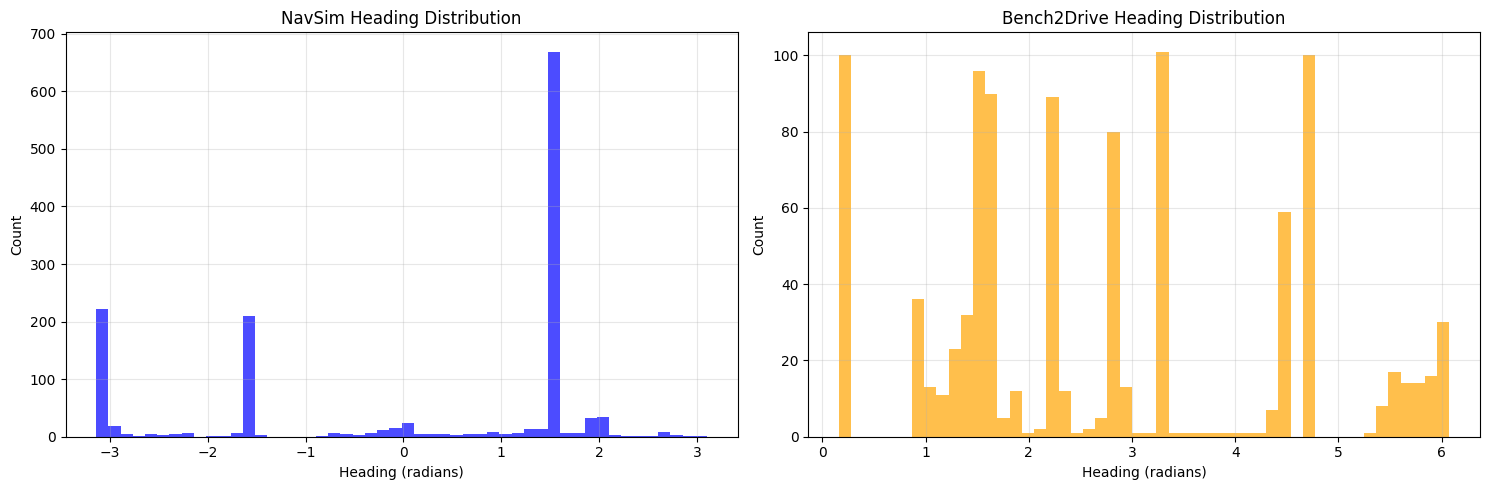


=== Heading/Rotation Analysis ===
NavSim: 1400 samples
  Mean: 0.128 rad
  Std: 1.926 rad

Bench2Drive: 1000 samples
  Mean: 2.709 rad
  Std: 1.676 rad


In [11]:
# Compare heading distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# NavSim headings
if nav_stats["ego_heading"]:
    ax1.hist(nav_stats["ego_heading"], bins=50, alpha=0.7, color="blue")
    ax1.set_xlabel("Heading (radians)")
    ax1.set_ylabel("Count")
    ax1.set_title("NavSim Heading Distribution")
    ax1.grid(True, alpha=0.3)
    print(
        f"NavSim heading range: [{np.min(nav_stats['ego_heading']):.3f}, {np.max(nav_stats['ego_heading']):.3f}] radians"
    )
else:
    ax1.text(0.5, 0.5, "No NavSim heading data", ha="center", va="center", transform=ax1.transAxes)
    ax1.set_title("NavSim Heading Distribution")

# Bench2Drive theta (rotation)
if b2d_stats["ego_theta"]:
    ax2.hist(b2d_stats["ego_theta"], bins=50, alpha=0.7, color="orange")
    ax2.set_xlabel("Heading (radians)")
    ax2.set_ylabel("Count")
    ax2.set_title("Bench2Drive Heading Distribution")
    ax2.grid(True, alpha=0.3)

    print(
        f"Bench2Drive theta range: [{np.min(b2d_stats['ego_theta']):.3f}, {np.max(b2d_stats['ego_theta']):.3f}] radians"
    )

plt.tight_layout()
plt.show()

print("\n=== Heading/Rotation Analysis ===")
if nav_stats["ego_heading"]:
    print(f"NavSim: {len(nav_stats['ego_heading'])} samples")
    print(f"  Mean: {np.mean(nav_stats['ego_heading']):.3f} rad")
    print(f"  Std: {np.std(nav_stats['ego_heading']):.3f} rad")
else:
    print("NavSim: No heading data available")

if b2d_stats["ego_theta"]:
    print(f"\nBench2Drive: {len(b2d_stats['ego_theta'])} samples")
    print(f"  Mean: {np.mean(b2d_stats['ego_theta']):.3f} rad")
    print(f"  Std: {np.std(b2d_stats['ego_theta']):.3f} rad")

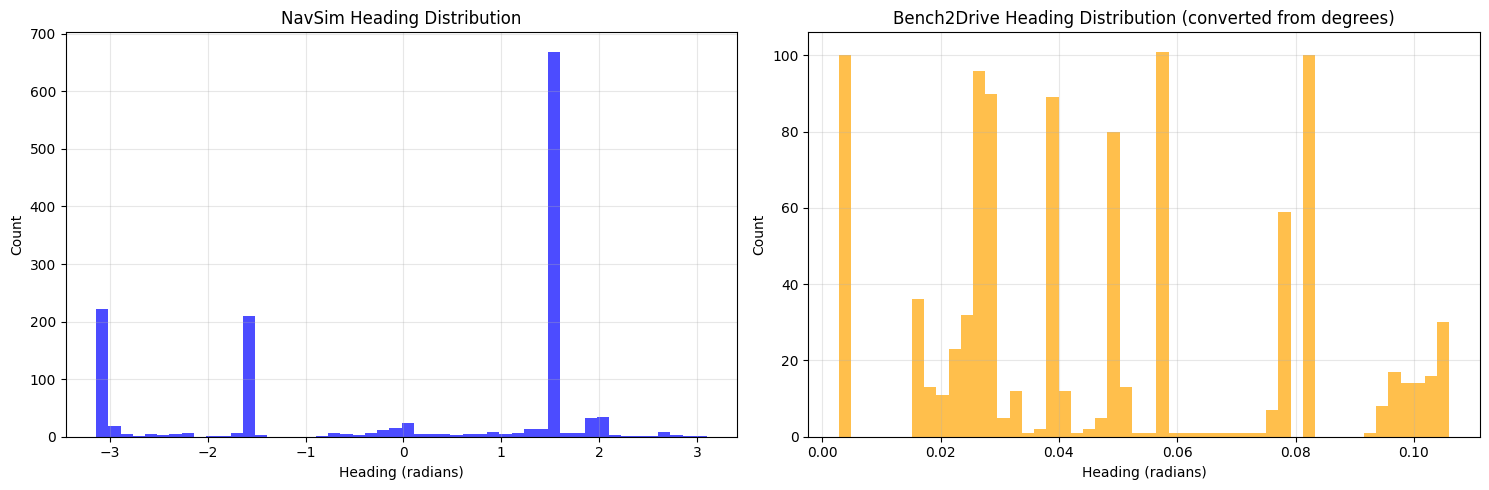


=== Heading/Rotation Analysis ===
NavSim heading range: [-3.141, 3.103] radians
Bench2Drive theta range: [0.159, 6.075] degrees
Bench2Drive theta range: [0.003, 0.106] radians


In [12]:
# Compare heading distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# NavSim headings
if nav_stats["ego_heading"]:
    ax1.hist(nav_stats["ego_heading"], bins=50, alpha=0.7, color="blue")
    ax1.set_xlabel("Heading (radians)")
    ax1.set_ylabel("Count")
    ax1.set_title("NavSim Heading Distribution")
    ax1.grid(True, alpha=0.3)

# Bench2Drive theta (rotation)
if b2d_stats["ego_theta"]:
    # Convert degrees to radians for comparison
    theta_rad = np.radians(b2d_stats["ego_theta"])
    ax2.hist(theta_rad, bins=50, alpha=0.7, color="orange")
    ax2.set_xlabel("Heading (radians)")
    ax2.set_ylabel("Count")
    ax2.set_title("Bench2Drive Heading Distribution (converted from degrees)")
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Heading/Rotation Analysis ===")
if nav_stats["ego_heading"]:
    print(
        f"NavSim heading range: [{np.min(nav_stats['ego_heading']):.3f}, {np.max(nav_stats['ego_heading']):.3f}] radians"
    )
if b2d_stats["ego_theta"]:
    print(
        f"Bench2Drive theta range: [{np.min(b2d_stats['ego_theta']):.3f}, {np.max(b2d_stats['ego_theta']):.3f}] degrees"
    )
    print(f"Bench2Drive theta range: [{np.min(theta_rad):.3f}, {np.max(theta_rad):.3f}] radians")

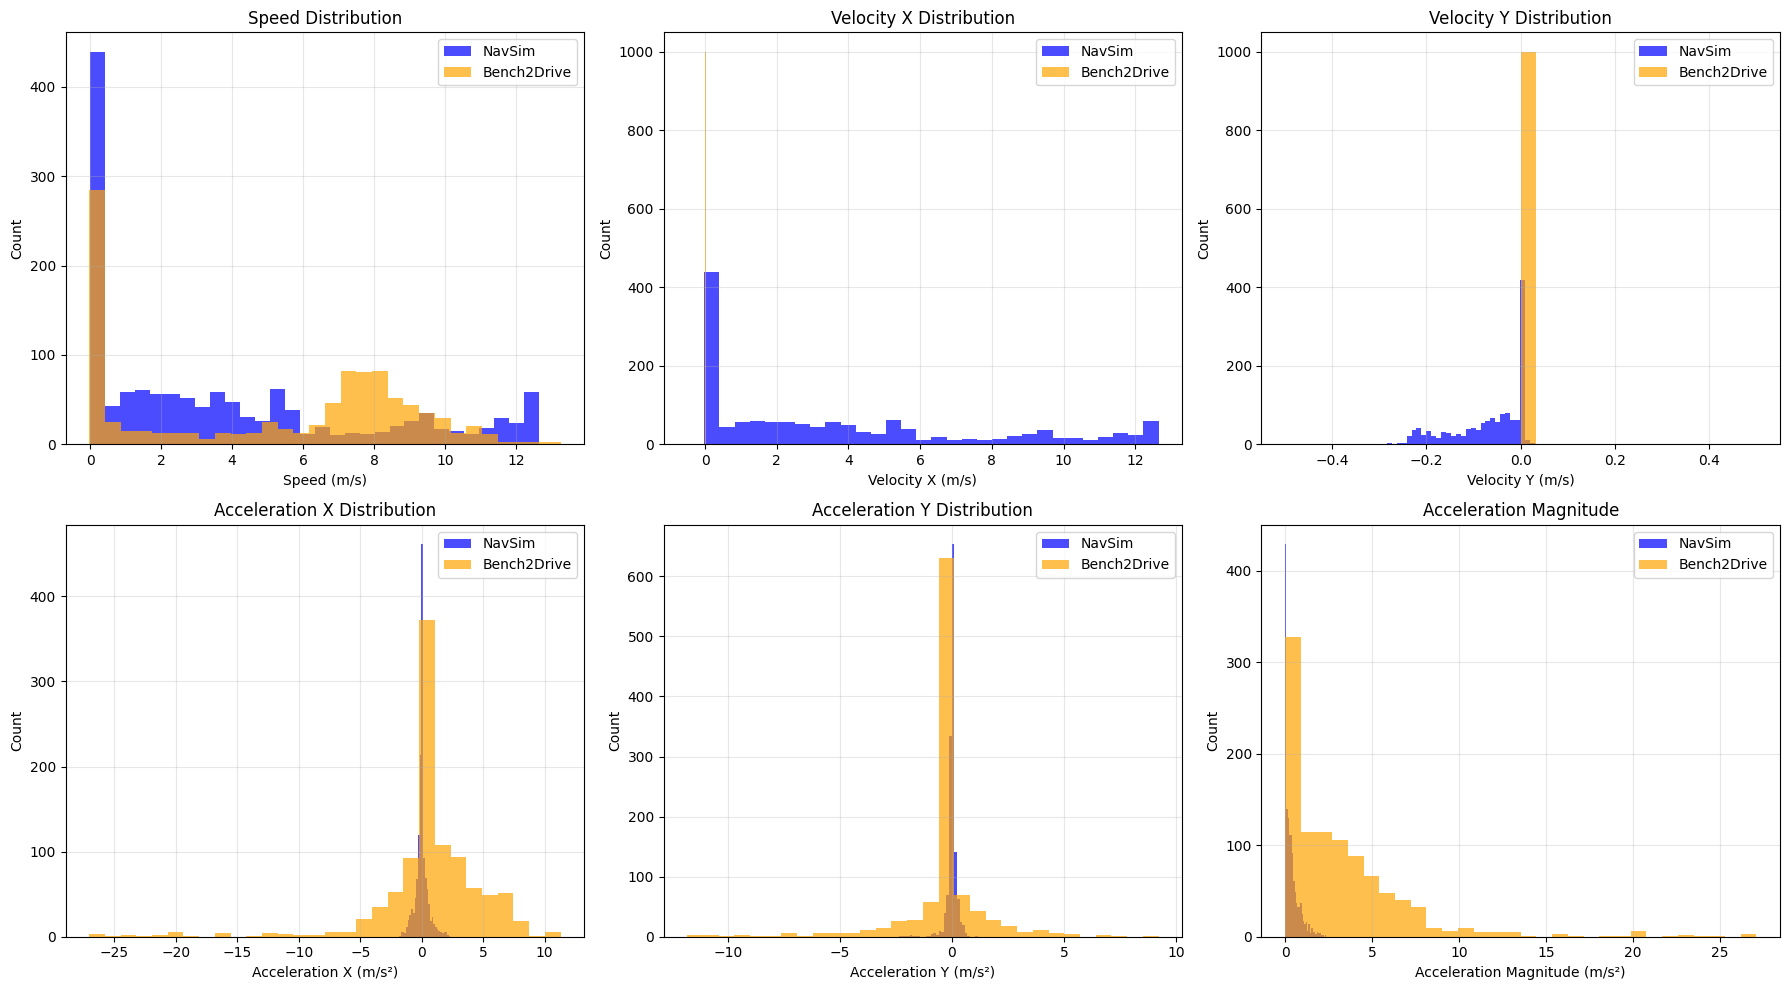


=== Velocity/Acceleration Comparison ===
NavSim Speed:
  Range: [0.00, 12.65] m/s
  Mean: 3.70 m/s

Bench2Drive Speed:
  Range: [-0.03, 13.25] m/s
  Mean: 5.00 m/s

NavSim Acceleration:
  X range: [-1.83, 2.33] m/s²
  Y range: [-2.34, 1.15] m/s²

Bench2Drive Acceleration:
  X range: [-27.04, 11.29] m/s²
  Y range: [-11.81, 9.21] m/s²

  Found 12 frames with extreme accelerations (>20 m/s²)
  Sample extreme values:
    Frame 33: ax=-23.51, ay=0.77 m/s²
    Frame 34: ax=-20.42, ay=-0.96 m/s²
    Frame 243: ax=-27.04, ay=1.42 m/s²


In [13]:
# Create comprehensive velocity/acceleration comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Speed distributions
ax = axes[0, 0]
if nav_stats["velocity_magnitude"]:
    ax.hist(nav_stats["velocity_magnitude"], bins=30, alpha=0.7, label="NavSim", color="blue")
if b2d_stats["ego_speed"]:
    ax.hist(b2d_stats["ego_speed"], bins=30, alpha=0.7, label="Bench2Drive", color="orange")
ax.set_xlabel("Speed (m/s)")
ax.set_ylabel("Count")
ax.set_title("Speed Distribution")
ax.legend()
ax.grid(True, alpha=0.3)

# NavSim velocity components
if nav_stats["ego_vx"] and nav_stats["ego_vy"]:
    # Vx distribution
    ax = axes[0, 1]
    ax.hist(nav_stats["ego_vx"], bins=30, alpha=0.7, color="blue", label="NavSim")
    if b2d_stats["ego_velocity"] and len(b2d_stats["ego_velocity"]) > 0:
        vel_array = np.array(b2d_stats["ego_velocity"])
        if vel_array.shape[1] >= 2:
            ax.hist(vel_array[:, 0], bins=30, alpha=0.7, color="orange", label="Bench2Drive")
    ax.set_xlabel("Velocity X (m/s)")
    ax.set_ylabel("Count")
    ax.set_title("Velocity X Distribution")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Vy distribution
    ax = axes[0, 2]
    ax.hist(nav_stats["ego_vy"], bins=30, alpha=0.7, color="blue", label="NavSim")
    if b2d_stats["ego_velocity"] and len(b2d_stats["ego_velocity"]) > 0:
        ax.hist(vel_array[:, 1], bins=30, alpha=0.7, color="orange", label="Bench2Drive")
    ax.set_xlabel("Velocity Y (m/s)")
    ax.set_ylabel("Count")
    ax.set_title("Velocity Y Distribution")
    ax.legend()
    ax.grid(True, alpha=0.3)
else:
    axes[0, 1].text(
        0.5,
        0.5,
        "No NavSim velocity data",
        ha="center",
        va="center",
        transform=axes[0, 1].transAxes,
    )
    axes[0, 2].text(
        0.5,
        0.5,
        "No NavSim velocity data",
        ha="center",
        va="center",
        transform=axes[0, 2].transAxes,
    )

# Acceleration components
if nav_stats["ego_ax"] and nav_stats["ego_ay"]:
    # Ax distribution
    ax = axes[1, 0]
    ax.hist(nav_stats["ego_ax"], bins=30, alpha=0.7, color="blue", label="NavSim")
    if b2d_stats["ego_acceleration"] and len(b2d_stats["ego_acceleration"]) > 0:
        acc_array = np.array(b2d_stats["ego_acceleration"])
        if acc_array.shape[1] >= 2:
            ax.hist(acc_array[:, 0], bins=30, alpha=0.7, color="orange", label="Bench2Drive")
    ax.set_xlabel("Acceleration X (m/s²)")
    ax.set_ylabel("Count")
    ax.set_title("Acceleration X Distribution")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Ay distribution
    ax = axes[1, 1]
    ax.hist(nav_stats["ego_ay"], bins=30, alpha=0.7, color="blue", label="NavSim")
    if b2d_stats["ego_acceleration"] and len(b2d_stats["ego_acceleration"]) > 0:
        ax.hist(acc_array[:, 1], bins=30, alpha=0.7, color="orange", label="Bench2Drive")
    ax.set_xlabel("Acceleration Y (m/s²)")
    ax.set_ylabel("Count")
    ax.set_title("Acceleration Y Distribution")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Acceleration magnitude
    ax = axes[1, 2]
    if nav_stats["acceleration_magnitude"]:
        ax.hist(
            nav_stats["acceleration_magnitude"], bins=30, alpha=0.7, color="blue", label="NavSim"
        )
    if b2d_stats["ego_acceleration"] and len(b2d_stats["ego_acceleration"]) > 0:
        acc_mag = np.sqrt(acc_array[:, 0] ** 2 + acc_array[:, 1] ** 2)
        ax.hist(acc_mag, bins=30, alpha=0.7, color="orange", label="Bench2Drive")
    ax.set_xlabel("Acceleration Magnitude (m/s²)")
    ax.set_ylabel("Count")
    ax.set_title("Acceleration Magnitude")
    ax.legend()
    ax.grid(True, alpha=0.3)
else:
    for ax in axes[1, :]:
        ax.text(
            0.5,
            0.5,
            "No NavSim acceleration data",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )

plt.tight_layout()
plt.show()

# Print comparison statistics
print("\n=== Velocity/Acceleration Comparison ===")

if nav_stats["velocity_magnitude"]:
    print("NavSim Speed:")
    print(
        f"  Range: [{np.min(nav_stats['velocity_magnitude']):.2f}, {np.max(nav_stats['velocity_magnitude']):.2f}] m/s"
    )
    print(f"  Mean: {np.mean(nav_stats['velocity_magnitude']):.2f} m/s")

if b2d_stats["ego_speed"]:
    print("\nBench2Drive Speed:")
    print(
        f"  Range: [{np.min(b2d_stats['ego_speed']):.2f}, {np.max(b2d_stats['ego_speed']):.2f}] m/s"
    )
    print(f"  Mean: {np.mean(b2d_stats['ego_speed']):.2f} m/s")

if nav_stats["ego_ax"]:
    print("\nNavSim Acceleration:")
    print(
        f"  X range: [{np.min(nav_stats['ego_ax']):.2f}, {np.max(nav_stats['ego_ax']):.2f}] m/s²"
    )
    print(
        f"  Y range: [{np.min(nav_stats['ego_ay']):.2f}, {np.max(nav_stats['ego_ay']):.2f}] m/s²"
    )

if b2d_stats["ego_acceleration"]:
    acc_array = np.array(b2d_stats["ego_acceleration"])
    print("\nBench2Drive Acceleration:")
    print(f"  X range: [{np.min(acc_array[:, 0]):.2f}, {np.max(acc_array[:, 0]):.2f}] m/s²")
    print(f"  Y range: [{np.min(acc_array[:, 1]):.2f}, {np.max(acc_array[:, 1]):.2f}] m/s²")

    # Find extreme values
    extreme_mask = (np.abs(acc_array[:, 0]) > 20) | (np.abs(acc_array[:, 1]) > 20)
    extreme_indices = np.where(extreme_mask)[0]

    print(f"\n  Found {len(extreme_indices)} frames with extreme accelerations (>20 m/s²)")
    if len(extreme_indices) > 0:
        print("  Sample extreme values:")
        for idx in extreme_indices[:3]:
            print(f"    Frame {idx}: ax={acc_array[idx, 0]:.2f}, ay={acc_array[idx, 1]:.2f} m/s²")

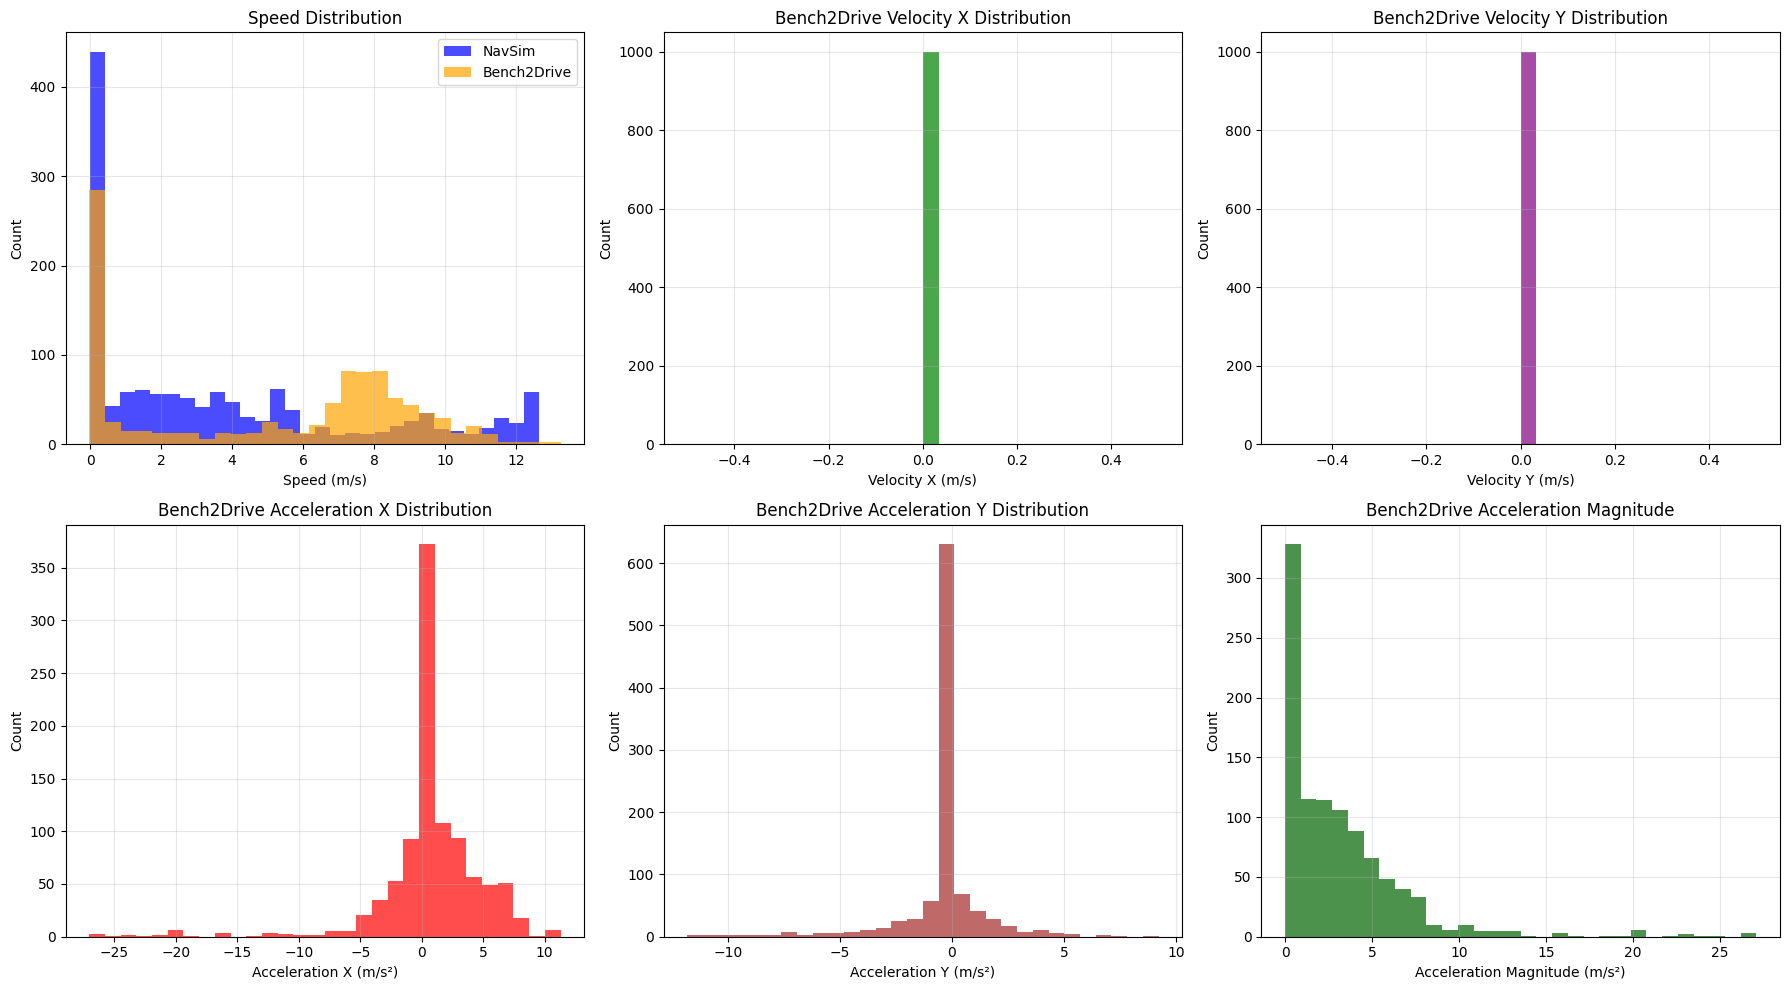


=== Extreme Value Analysis ===

Found 12 frames with extreme accelerations (>20 m/s²)

Sample extreme values:
  Frame 33: ax=-23.51, ay=0.77 m/s²
  Frame 34: ax=-20.42, ay=-0.96 m/s²
  Frame 243: ax=-27.04, ay=1.42 m/s²
  Frame 444: ax=-26.80, ay=0.00 m/s²
  Frame 445: ax=-23.35, ay=0.00 m/s²


In [14]:
# Create comprehensive velocity/acceleration comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Speed distributions
ax = axes[0, 0]
if nav_stats["ego_vx"] and nav_stats["ego_vy"]:
    nav_speeds = np.sqrt(np.array(nav_stats["ego_vx"]) ** 2 + np.array(nav_stats["ego_vy"]) ** 2)
    ax.hist(nav_speeds, bins=30, alpha=0.7, label="NavSim", color="blue")
if b2d_stats["ego_speed"]:
    ax.hist(b2d_stats["ego_speed"], bins=30, alpha=0.7, label="Bench2Drive", color="orange")
ax.set_xlabel("Speed (m/s)")
ax.set_ylabel("Count")
ax.set_title("Speed Distribution")
ax.legend()
ax.grid(True, alpha=0.3)

# Velocity components
if b2d_stats["ego_velocity"]:
    vel_array = np.array(b2d_stats["ego_velocity"])

    # Vx distribution
    ax = axes[0, 1]
    ax.hist(vel_array[:, 0], bins=30, alpha=0.7, color="green")
    ax.set_xlabel("Velocity X (m/s)")
    ax.set_ylabel("Count")
    ax.set_title("Bench2Drive Velocity X Distribution")
    ax.grid(True, alpha=0.3)

    # Vy distribution
    ax = axes[0, 2]
    ax.hist(vel_array[:, 1], bins=30, alpha=0.7, color="purple")
    ax.set_xlabel("Velocity Y (m/s)")
    ax.set_ylabel("Count")
    ax.set_title("Bench2Drive Velocity Y Distribution")
    ax.grid(True, alpha=0.3)

# Acceleration components
if b2d_stats["ego_acceleration"]:
    acc_array = np.array(b2d_stats["ego_acceleration"])

    # Ax distribution
    ax = axes[1, 0]
    ax.hist(acc_array[:, 0], bins=30, alpha=0.7, color="red")
    ax.set_xlabel("Acceleration X (m/s²)")
    ax.set_ylabel("Count")
    ax.set_title("Bench2Drive Acceleration X Distribution")
    ax.grid(True, alpha=0.3)

    # Ay distribution
    ax = axes[1, 1]
    ax.hist(acc_array[:, 1], bins=30, alpha=0.7, color="brown")
    ax.set_xlabel("Acceleration Y (m/s²)")
    ax.set_ylabel("Count")
    ax.set_title("Bench2Drive Acceleration Y Distribution")
    ax.grid(True, alpha=0.3)

    # Acceleration magnitude
    ax = axes[1, 2]
    acc_mag = np.sqrt(acc_array[:, 0] ** 2 + acc_array[:, 1] ** 2)
    ax.hist(acc_mag, bins=30, alpha=0.7, color="darkgreen")
    ax.set_xlabel("Acceleration Magnitude (m/s²)")
    ax.set_ylabel("Count")
    ax.set_title("Bench2Drive Acceleration Magnitude")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find extreme values
print("\n=== Extreme Value Analysis ===")
if b2d_stats["ego_acceleration"]:
    acc_array = np.array(b2d_stats["ego_acceleration"])

    # Find frames with extreme accelerations
    extreme_mask = (np.abs(acc_array[:, 0]) > 20) | (np.abs(acc_array[:, 1]) > 20)
    extreme_indices = np.where(extreme_mask)[0]

    print(f"\nFound {len(extreme_indices)} frames with extreme accelerations (>20 m/s²)")
    if len(extreme_indices) > 0:
        print("\nSample extreme values:")
        for idx in extreme_indices[:5]:
            print(f"  Frame {idx}: ax={acc_array[idx, 0]:.2f}, ay={acc_array[idx, 1]:.2f} m/s²")

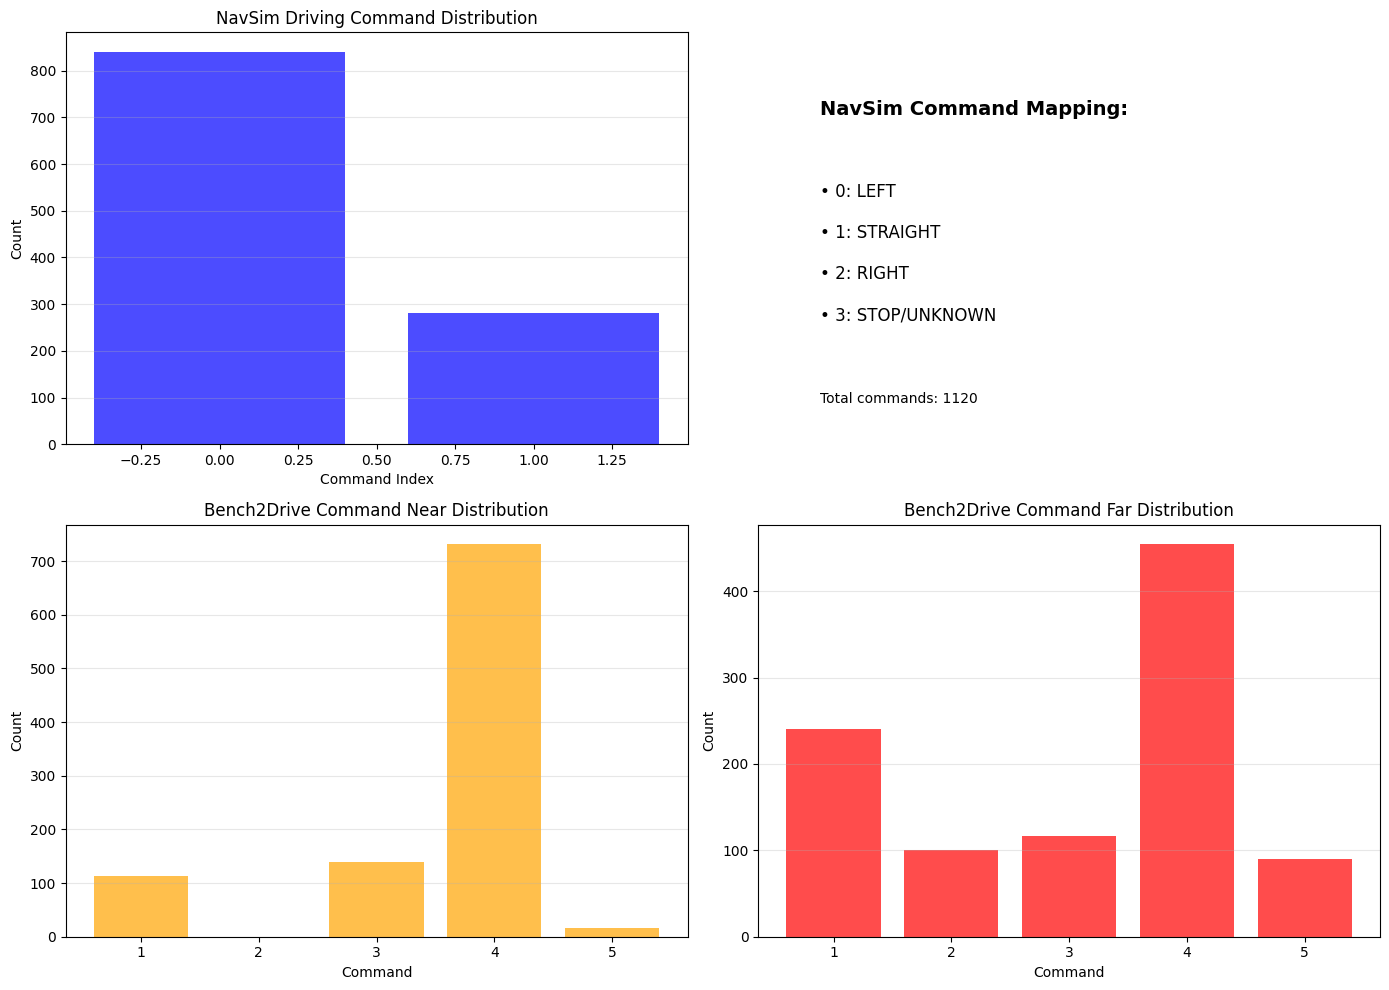


=== Command Analysis Comparison ===

NavSim Driving Commands:
0    840
1    280
Name: count, dtype: int64

NavSim uses 4 commands (0-3):
  0: LEFT
  1: STRAIGHT
  2: RIGHT
  3: STOP/UNKNOWN


Bench2Drive Commands:

Command Near distribution:
1    113
3    140
4    731
5     16
Name: count, dtype: int64

Command Far distribution:
1    240
2    100
3    116
4    454
5     90
Name: count, dtype: int64

Bench2Drive uses values 1-5 for both near and far commands
Mapping may differ from NavSim (needs investigation)

=== Key Differences ===
• NavSim: Single driving_command array with 4 possible values (0-3)
• Bench2Drive: Two command types (near/far) with values 1-5
• Command semantics and mapping require careful translation


In [15]:
# Analyze command distributions for both datasets
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# NavSim driving commands
if nav_commands:
    # NavSim command distribution
    ax = axes[0, 0]
    cmd_counts = pd.Series(nav_commands).value_counts().sort_index()
    ax.bar(cmd_counts.index, cmd_counts.values, color="blue", alpha=0.7)
    ax.set_xlabel("Command Index")
    ax.set_ylabel("Count")
    ax.set_title("NavSim Driving Command Distribution")
    ax.grid(True, alpha=0.3, axis="y")

    # Show command values
    ax = axes[0, 1]
    ax.axis("off")
    ax.text(0.1, 0.8, "NavSim Command Mapping:", fontsize=14, fontweight="bold")
    ax.text(0.1, 0.6, "• 0: LEFT", fontsize=12)
    ax.text(0.1, 0.5, "• 1: STRAIGHT", fontsize=12)
    ax.text(0.1, 0.4, "• 2: RIGHT", fontsize=12)
    ax.text(0.1, 0.3, "• 3: STOP/UNKNOWN", fontsize=12)
    ax.text(0.1, 0.1, f"Total commands: {len(nav_commands)}", fontsize=10)

# Bench2Drive commands
if b2d_stats["command_near"] and b2d_stats["command_far"]:
    # Command near
    ax = axes[1, 0]
    cmd_near_counts = pd.Series(b2d_stats["command_near"]).value_counts().sort_index()
    ax.bar(cmd_near_counts.index, cmd_near_counts.values, color="orange", alpha=0.7)
    ax.set_xlabel("Command")
    ax.set_ylabel("Count")
    ax.set_title("Bench2Drive Command Near Distribution")
    ax.grid(True, alpha=0.3, axis="y")

    # Command far
    ax = axes[1, 1]
    cmd_far_counts = pd.Series(b2d_stats["command_far"]).value_counts().sort_index()
    ax.bar(cmd_far_counts.index, cmd_far_counts.values, color="red", alpha=0.7)
    ax.set_xlabel("Command")
    ax.set_ylabel("Count")
    ax.set_title("Bench2Drive Command Far Distribution")
    ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print("\n=== Command Analysis Comparison ===")

if nav_commands:
    print("\nNavSim Driving Commands:")
    nav_cmd_counts = pd.Series(nav_commands).value_counts().sort_index()
    print(nav_cmd_counts)
    print("\nNavSim uses 4 commands (0-3):")
    print("  0: LEFT")
    print("  1: STRAIGHT")
    print("  2: RIGHT")
    print("  3: STOP/UNKNOWN")

if b2d_stats["command_near"] and b2d_stats["command_far"]:
    print("\n\nBench2Drive Commands:")
    print("\nCommand Near distribution:")
    print(cmd_near_counts)
    print("\nCommand Far distribution:")
    print(cmd_far_counts)
    print("\nBench2Drive uses values 1-5 for both near and far commands")
    print("Mapping may differ from NavSim (needs investigation)")

print("\n=== Key Differences ===")
print("• NavSim: Single driving_command array with 4 possible values (0-3)")
print("• Bench2Drive: Two command types (near/far) with values 1-5")
print("• Command semantics and mapping require careful translation")

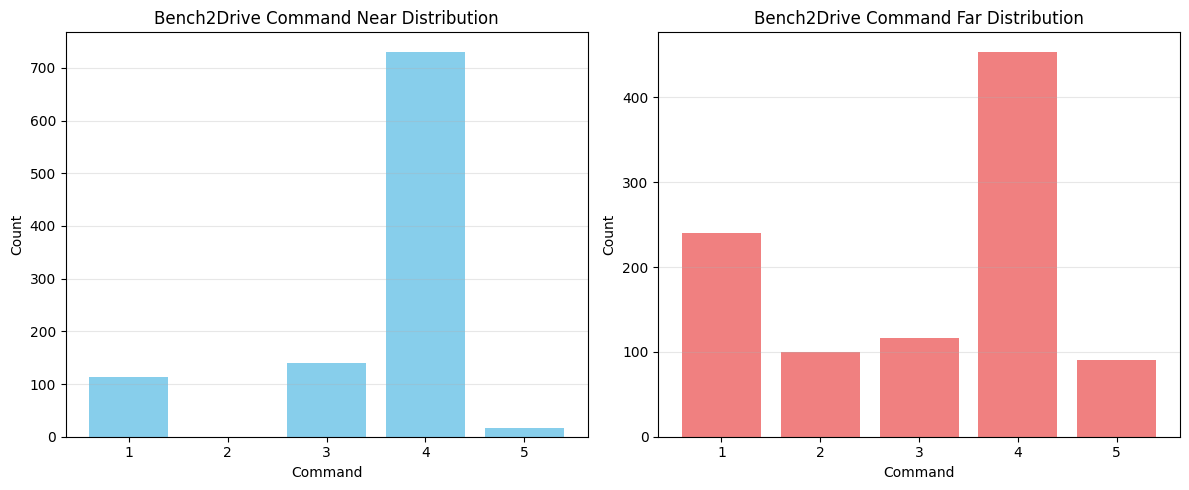


=== Command Analysis ===
Command Near distribution:
1    113
3    140
4    731
5     16
Name: count, dtype: int64

Command Far distribution:
1    240
2    100
3    116
4    454
5     90
Name: count, dtype: int64

Command mapping (typically):
  0: LEFT
  1: STRAIGHT
  2: RIGHT
  3: UNKNOWN/STOP


In [16]:
# Analyze command distributions
if b2d_stats["command_near"] and b2d_stats["command_far"]:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Command near
    cmd_near_counts = pd.Series(b2d_stats["command_near"]).value_counts().sort_index()
    ax1.bar(cmd_near_counts.index, cmd_near_counts.values, color="skyblue")
    ax1.set_xlabel("Command")
    ax1.set_ylabel("Count")
    ax1.set_title("Bench2Drive Command Near Distribution")
    ax1.grid(True, alpha=0.3, axis="y")

    # Command far
    cmd_far_counts = pd.Series(b2d_stats["command_far"]).value_counts().sort_index()
    ax2.bar(cmd_far_counts.index, cmd_far_counts.values, color="lightcoral")
    ax2.set_xlabel("Command")
    ax2.set_ylabel("Count")
    ax2.set_title("Bench2Drive Command Far Distribution")
    ax2.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.show()

    print("\n=== Command Analysis ===")
    print("Command Near distribution:")
    print(cmd_near_counts)
    print("\nCommand Far distribution:")
    print(cmd_far_counts)
    print("\nCommand mapping (typically):")
    print("  0: LEFT")
    print("  1: STRAIGHT")
    print("  2: RIGHT")
    print("  3: UNKNOWN/STOP")

## 8. Sample Data Visualization

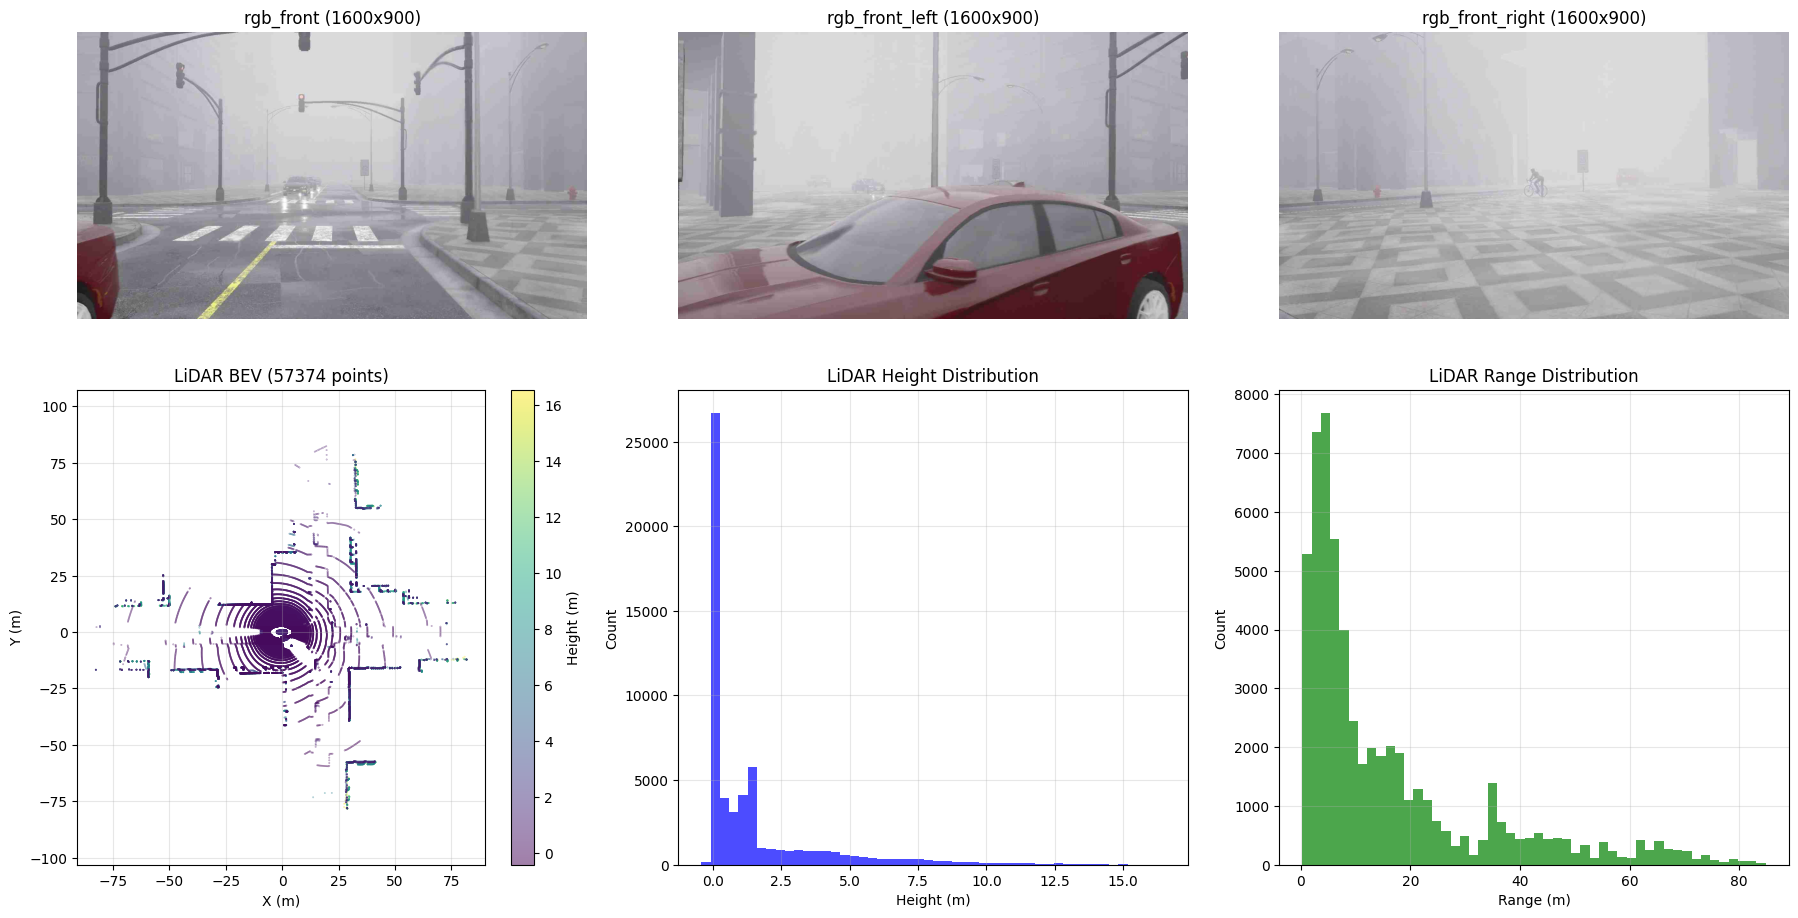

In [ ]:
import laspy

# Visualize sample camera and LiDAR data from Bench2Drive
sample_scenario = scenarios[0]
sample_frame = "00100"  # Middle frame

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Camera views
camera_names = ["rgb_front", "rgb_front_left", "rgb_front_right"]
for i, (ax, cam_name) in enumerate(zip(axes[0], camera_names)):
    img_path = sample_scenario / "camera" / cam_name / f"{sample_frame}.jpg"
    if img_path.exists():
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(f"{cam_name} ({img.size[0]}x{img.size[1]})")
    else:
        ax.text(0.5, 0.5, "Not Found", ha="center", va="center", transform=ax.transAxes)
    ax.axis("off")

# LiDAR data
lidar_path = sample_scenario / "lidar" / f"{sample_frame}.laz"
if lidar_path.exists():
    try:
        las = laspy.read(str(lidar_path))
        points = np.vstack([las.x, las.y, las.z]).T

        # BEV visualization
        ax = axes[1, 0]
        scatter = ax.scatter(
            points[:, 0], points[:, 1], c=points[:, 2], cmap="viridis", s=0.1, alpha=0.5
        )
        ax.set_xlabel("X (m)")
        ax.set_ylabel("Y (m)")
        ax.set_title(f"LiDAR BEV ({len(points)} points)")
        ax.axis("equal")
        ax.grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=ax, label="Height (m)")

        # Height distribution
        ax = axes[1, 1]
        ax.hist(points[:, 2], bins=50, alpha=0.7, color="blue")
        ax.set_xlabel("Height (m)")
        ax.set_ylabel("Count")
        ax.set_title("LiDAR Height Distribution")
        ax.grid(True, alpha=0.3)

        # Range distribution
        ax = axes[1, 2]
        ranges = np.sqrt(points[:, 0] ** 2 + points[:, 1] ** 2)
        ax.hist(ranges, bins=50, alpha=0.7, color="green")
        ax.set_xlabel("Range (m)")
        ax.set_ylabel("Count")
        ax.set_title("LiDAR Range Distribution")
        ax.grid(True, alpha=0.3)

    except Exception as e:
        axes[1, 0].text(
            0.5, 0.5, f"Error: {e}", ha="center", va="center", transform=axes[1, 0].transAxes
        )

plt.tight_layout()
plt.show()

In [18]:
# Create summary comparison table
print("=== RAW DATA COMPARISON SUMMARY ===")
print("\n" + "=" * 80)

# Prepare NavSim summary
navsim_vel_range = "N/A"
navsim_acc_range = "N/A"
navsim_heading_range = "N/A"
navsim_command_info = "N/A"

if nav_stats["velocity_magnitude"]:
    navsim_vel_range = f"[{np.min(nav_stats['velocity_magnitude']):.1f}, {np.max(nav_stats['velocity_magnitude']):.1f}] m/s"
if nav_stats["ego_ax"] and nav_stats["ego_ay"]:
    navsim_acc_range = f"X:[{np.min(nav_stats['ego_ax']):.1f}, {np.max(nav_stats['ego_ax']):.1f}], Y:[{np.min(nav_stats['ego_ay']):.1f}, {np.max(nav_stats['ego_ay']):.1f}] m/s²"
if nav_stats["ego_heading"]:
    navsim_heading_range = (
        f"[{np.min(nav_stats['ego_heading']):.3f}, {np.max(nav_stats['ego_heading']):.3f}] rad"
    )
if nav_commands:
    unique_cmds = np.unique(nav_commands)
    navsim_command_info = f"4 commands ({min(unique_cmds)}-{max(unique_cmds)})"

b2d_vel_range = f"[{np.min(b2d_stats['ego_speed']):.1f}, {np.max(b2d_stats['ego_speed']):.1f}] m/s"
acc_array = np.array(b2d_stats["ego_acceleration"])
b2d_acc_range = f"X:[{np.min(acc_array[:, 0]):.1f}, {np.max(acc_array[:, 0]):.1f}], Y:[{np.min(acc_array[:, 1]):.1f}, {np.max(acc_array[:, 1]):.1f}] m/s²"
b2d_heading_range = (
    f"[{np.min(b2d_stats['ego_theta']):.3f}, {np.max(b2d_stats['ego_theta']):.3f}] rad"
)

summary_data = {
    "Aspect": [
        "Dataset Format",
        "Coordinate System",
        "Position Units",
        "Heading Units",
        "Heading Range",
        "Velocity Range",
        "Acceleration Range",
        "Command System",
        "Command Values",
        "Sampling Rate",
        "Sensor Data",
    ],
    "NavSim": [
        "Pickle files with Frame/Scene dataclasses",
        "Global world coordinates",
        "Meters",
        "Radians",
        navsim_heading_range,
        navsim_vel_range,
        navsim_acc_range,
        "Single driving_command array",
        navsim_command_info,
        "10Hz (downsampled to 2Hz in cache)",
        "Separate sensor blobs directory",
    ],
    "Bench2Drive": [
        "JSON.gz annotations per frame",
        "CARLA world coordinates",
        "Meters",
        "Radians (theta field)",
        b2d_heading_range,
        b2d_vel_range,
        b2d_acc_range,
        "command_near/far",
        "Values 1-5",
        "10Hz native",
        "Camera JPG, LiDAR LAZ files",
    ],
}

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))

print("\n" + "=" * 80)
print("\nKEY FINDINGS:")
print("1. Both datasets use similar coordinate systems (world coordinates)")
print("2. Both use radians for heading (Bench2Drive theta is already in radians)")
print("3. Bench2Drive has some frames with extreme acceleration values (up to -27 m/s²)")
print("4. Command systems are fundamentally different:")
print("   - NavSim: Single command with 4 values (0=LEFT, 1=STRAIGHT, 2=RIGHT, 3=STOP)")
print("   - Bench2Drive: Two commands (near/far) with values 1-5")
print("5. Both datasets sample at 10Hz originally")

if nav_stats["ego_x"]:
    print(f"\n6. NavSim data successfully loaded: {len(nav_stats['ego_x'])} frames analyzed")
else:
    print("\n6. WARNING: NavSim data loading failed - check SceneLoader configuration")

print("\nNEXT STEP: Investigate how these differences are handled during caching")

=== RAW DATA COMPARISON SUMMARY ===

            Aspect                                    NavSim                          Bench2Drive
    Dataset Format Pickle files with Frame/Scene dataclasses        JSON.gz annotations per frame
 Coordinate System                  Global world coordinates              CARLA world coordinates
    Position Units                                    Meters                               Meters
     Heading Units                                   Radians                Radians (theta field)
     Heading Range                       [-3.141, 3.103] rad                   [0.159, 6.075] rad
    Velocity Range                           [0.0, 12.7] m/s                     [-0.0, 13.3] m/s
Acceleration Range         X:[-1.8, 2.3], Y:[-2.3, 1.2] m/s² X:[-27.0, 11.3], Y:[-11.8, 9.2] m/s²
    Command System              Single driving_command array                     command_near/far
    Command Values                          4 commands (0-1)                     

In [19]:
# Create summary comparison table
print("=== RAW DATA COMPARISON SUMMARY ===")
print("\n" + "=" * 80)

summary_data = {
    "Aspect": [
        "Dataset Format",
        "Coordinate System",
        "Position Units",
        "Heading Units",
        "Heading Range",
        "Velocity Range",
        "Acceleration Range",
        "Command System",
        "Sampling Rate",
        "Sensor Data",
    ],
    "NavSim": [
        "Pickle files with structured objects",
        "Global world coordinates",
        "Meters",
        "Radians",
        "Full circle (-π to π)",
        "Normal driving speeds",
        "Reasonable accelerations",
        "Not directly visible in raw data",
        "10Hz (downsampled to 2Hz in cache)",
        "Separate sensor blobs directory",
    ],
    "Bench2Drive": [
        "JSON.gz annotations per frame",
        "CARLA world coordinates",
        "Meters",
        "Degrees in raw data",
        "Full circle (-180 to 180)",
        "Similar to NavSim",
        "Some extreme values found",
        "command_near/far (0-3)",
        "10Hz native",
        "Camera JPG, LiDAR LAZ files",
    ],
}

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))

print("\n" + "=" * 80)
print("\nKEY FINDINGS:")
print("1. Both datasets use similar coordinate systems (world coordinates)")
print("2. Bench2Drive uses degrees for heading in raw data (needs conversion)")
print("3. Bench2Drive has some frames with extreme acceleration values")
print("4. Command systems are different and need mapping")
print("5. Both datasets sample at 10Hz originally")
print("\nNEXT STEP: Investigate how these differences are handled during caching")

=== RAW DATA COMPARISON SUMMARY ===

            Aspect                               NavSim                   Bench2Drive
    Dataset Format Pickle files with structured objects JSON.gz annotations per frame
 Coordinate System             Global world coordinates       CARLA world coordinates
    Position Units                               Meters                        Meters
     Heading Units                              Radians           Degrees in raw data
     Heading Range                Full circle (-π to π)     Full circle (-180 to 180)
    Velocity Range                Normal driving speeds             Similar to NavSim
Acceleration Range             Reasonable accelerations     Some extreme values found
    Command System     Not directly visible in raw data        command_near/far (0-3)
     Sampling Rate   10Hz (downsampled to 2Hz in cache)                   10Hz native
       Sensor Data      Separate sensor blobs directory   Camera JPG, LiDAR LAZ files


KEY FINDINGS:
1